# Ecommerce Analysis

#### In an environment where data drives strategic decision-making, this project demonstrates the use of Python to clean, analyze, and visualize client data—particularly in support of financial advisors. Utilizing powerful libraries such as pandas for data manipulation, NumPy for numerical operations, matplotlib and seaborn for visualization, and Plotly for interactive dashboard components, this project builds a foundation for producing clear, client-ready reports. Emphasis is placed on integrating and preparing data from multiple sources, ensuring accuracy, consistency, and insight-rich outputs that support real-time decision-making in a fast-growing business context.



## Table of contents

## Table of Contents
- [Libraries and data cleansing](#Libraries-and-data-cleansing)
- [Customer Segmentation Foundation](#Customer-Segmentation-Foundation)

### Libraries and data cleansing

In [3]:
import pandas as pd

In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [5]:
maindf = pd.read_csv(r"C:\Users\user1\OneDrive\Documents\Ecommerce_Consumer_Behavior_Analysis_Data.csv")

In [42]:
maindf = pd.read_csv(
    r"C:\Users\user1\OneDrive\Documents\Ecommerce_Consumer_Behavior_Analysis_Data.csv",
    converters={
        'Purchase_Amount': lambda x: str(x).replace('$', '').replace(',', '').strip()
    }
)
maindf['Purchase_Amount'] = pd.to_numeric(maindf['Purchase_Amount'], errors='coerce')

In [43]:
maindf.head()

,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
0,37-611-6911,22,Female,Middle,Married,Bachelor's,Middle,Évry,Gardening & Outdoors,333.80,...,7,NaN,Tablet,Credit Card,3/1/2024,True,False,Need-based,No Preference,2
1,29-392-9296,49,Male,High,Married,High School,High,Huocheng,Food & Beverages,222.22,...,5,High,Tablet,PayPal,4/16/2024,True,False,Wants-based,Standard,6
2,84-649-5117,24,Female,Middle,Single,Master's,High,Huzhen,Office Supplies,426.22,...,7,Low,Smartphone,Debit Card,3/15/2024,True,True,Impulsive,No Preference,3
3,48-980-6078,29,Female,Middle,Single,Master's,Middle,Wiwilí,Home Appliances,101.31,...,1,NaN,Smartphone,Other,10/4/2024,True,True,Need-based,Express,10
4,91-170-9072,33,Female,Middle,Widowed,High School,Middle,Nara,Furniture,211.70,...,10,NaN,Smartphone,Debit Card,1/30/2024,False,False,Wants-based,No Preference,4


In [44]:
maindf.shape

(1000, 28)

In [45]:
maindf.isnull().sum()

Customer_ID                                0
Age                                        0
Gender                                     0
Income_Level                               0
Marital_Status                             0
Education_Level                            0
Occupation                                 0
Location                                   0
Purchase_Category                          0
Purchase_Amount                            0
Frequency_of_Purchase                      0
Purchase_Channel                           0
Brand_Loyalty                              0
Product_Rating                             0
Time_Spent_on_Product_Research(hours)      0
Social_Media_Influence                   247
Discount_Sensitivity                       0
Return_Rate                                0
Customer_Satisfaction                      0
Engagement_with_Ads                      256
Device_Used_for_Shopping                   0
Payment_Method                             0
Time_of_Pu

In [46]:
maindf['Social_Media_Influence'] = maindf['Social_Media_Influence'].fillna(maindf['Social_Media_Influence'].mode()[0])

In [47]:
maindf['Engagement_with_Ads'] = maindf['Engagement_with_Ads'].fillna(maindf['Engagement_with_Ads'].mode()[0])

In [48]:
maindf.duplicated().sum()

0

In [49]:
maindf.dtypes

Customer_ID                               object
Age                                        int64
Gender                                    object
Income_Level                              object
Marital_Status                            object
Education_Level                           object
Occupation                                object
Location                                  object
Purchase_Category                         object
Purchase_Amount                          float64
Frequency_of_Purchase                      int64
Purchase_Channel                          object
Brand_Loyalty                              int64
Product_Rating                             int64
Time_Spent_on_Product_Research(hours)    float64
Social_Media_Influence                    object
Discount_Sensitivity                      object
Return_Rate                                int64
Customer_Satisfaction                      int64
Engagement_with_Ads                       object
Device_Used_for_Shop

In [50]:
maindf['Purchase_Amount'] = pd.to_numeric(maindf['Purchase_Amount'], errors='coerce')
maindf['Engagement_with_Ads'] = pd.to_numeric(maindf['Engagement_with_Ads'], errors='coerce')
maindf['Time_of_Purchase'] = pd.to_datetime(maindf['Time_of_Purchase'], errors='coerce')

In [51]:
maindf.describe(include='all')

,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
count,1000,1000.000000,1000,1000,1000,1000,1000,1000,1000,1000.000000,...,1000.000000,0.0,1000,1000,1000,1000,1000,1000,1000,1000.000000
unique,1000,NaN,8,2,4,3,2,969,24,NaN,...,NaN,NaN,3,5,NaN,2,2,4,3,NaN
top,37-611-6911,NaN,Female,High,Widowed,Bachelor's,High,Oslo,Electronics,NaN,...,NaN,NaN,Desktop,PayPal,NaN,True,False,Need-based,No Preference,NaN
freq,1,NaN,452,515,260,341,517,4,54,NaN,...,NaN,NaN,350,219,NaN,521,509,256,372,NaN
mean,NaN,34.304000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,275.063880,...,5.399000,NaN,NaN,NaN,2024-06-29 06:31:40.800000,NaN,NaN,NaN,NaN,7.547000
min,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.710000,...,1.000000,NaN,NaN,NaN,2024-01-01 00:00:00,NaN,NaN,NaN,NaN,1.000000
25%,NaN,26.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,162.235000,...,3.000000,NaN,NaN,NaN,2024-04-04 00:00:00,NaN,NaN,NaN,NaN,4.000000
50%,NaN,34.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,276.165000,...,5.000000,NaN,NaN,NaN,2024-06-30 00:00:00,NaN,NaN,NaN,NaN,8.000000
75%,NaN,42.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,388.982500,...,8.000000,NaN,NaN,NaN,2024-09-19 00:00:00,NaN,NaN,NaN,NaN,11.000000
max,NaN,50.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,498.330000,...,10.000000,NaN,NaN,NaN,2024-12-30 00:00:00,NaN,NaN,NaN,NaN,14.000000


In [52]:
maindf['Purchase_Amount'] = maindf['Purchase_Amount'].replace('[\$,]', '', regex=True).astype(float)

### Customer Segmentation Foundation

##### Profile who buys more
##### Understand when people shop
##### Identify potential drivers of purchase amount or intent

In [53]:
gender_group = maindf.groupby('Gender')['Purchase_Amount'].agg(['mean', 'median', 'count']).sort_values(by='mean', ascending=False)
print("Purchase by Gender:\n", gender_group)

Purchase by Gender:
                    mean   median  count
Gender                                 
Polygender   308.108000  305.450     15
Genderfluid  295.223529  282.130     17
Non-binary   287.730625  301.885     16
Female       282.087854  281.850    452
Genderqueer  279.517500  267.090     12
Male         267.618463  263.500    449
Bigender     258.469500  254.060     20
Agender      243.777368  198.450     19


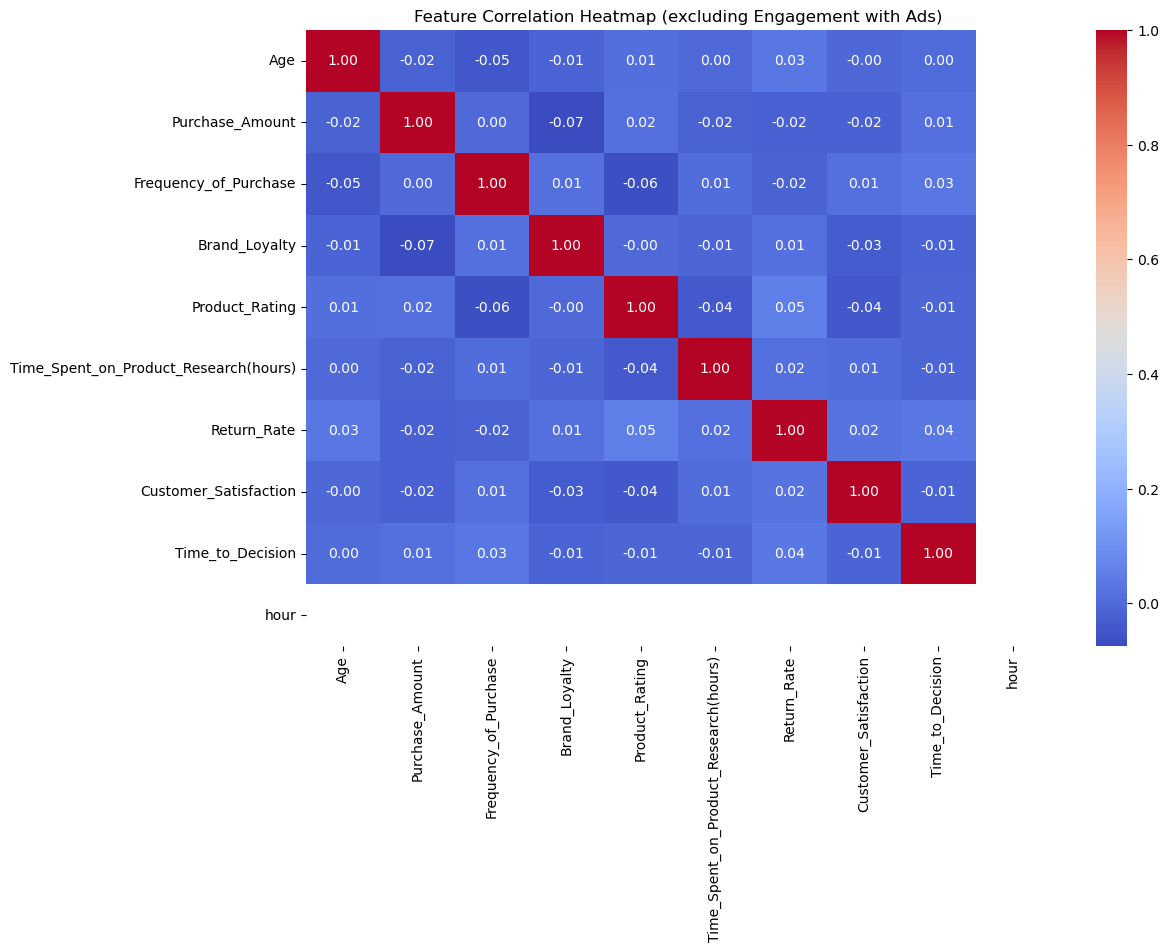

In [80]:
numeric_df = maindf.select_dtypes(include=np.number)
numeric_df = numeric_df.drop(columns=['Engagement_with_Ads'], errors='ignore')
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap (excluding Engagement with Ads)")
plt.show()

#### looking at the heatmap we can see possible correlations between purchase amount-brand loyality, product rating-frequency of purchase, and frequency of purchase-age. It seems as if brand loyality, product rating, and age are the biggest factors when it comes to the amount purchased and frequency of purchases.